**Learning Curves for Linear Regression**

Learning curves help us understand how a model's performance changes as we increase the training data size. A plot of training error and validation error versus training set size can provide insights into whether a model is underfitting, overfitting, or performing well.

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , mean_absolute_percentage_error
from sklearn.datasets import fetch_openml

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [94]:
# Load the California housing dataset from OpenML
housing_sale = fetch_openml(name='house_sales', version=1,parser='pandas',target_column='price')
housing_sale.data.drop('date',axis=1,inplace=True)
X = housing_sale.data
y = housing_sale.target

C:\Users\Lbundi\AppData\Local\Temp\ipykernel_25188\223570986.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  housing_sale.data.drop('date',axis=1,inplace=True)


In [95]:
# Display data types to check for categorical features
print(X.dtypes)

bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


In [96]:
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()
numeric_features     = X.select_dtypes(include=['int64','float64']).columns.tolist()

# Preprocessor for numeric data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessor for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing for both types of data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Preprocess the data
X_processed = preprocessor.fit_transform(X)




In [97]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

In [104]:
def plot_learning_curves(model, X_train, y_train, X_val, y_val):
    train_errors, val_errors = [], []
    
    for m in range(1, len(X_train)):
        
        model.fit(X_train[:m], y_train[:m])
        y_train_predict  = model.predict(X_train[:m])
        y_val_predict    = model.predict(X_val)
        train_errors.append(mean_absolute_percentage_error(y_train[:m], y_train_predict))
        val_errors.append(mean_absolute_percentage_error(y_val, y_val_predict))

    plt.figure(figsize=(10, 6))
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="Training Error")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=2, label="Validation Error")
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training Set Size", fontsize=14)
    plt.ylabel("Mean Absolute Percentage error", fontsize=14)
    plt.title("Learning Curves")
    plt.show()


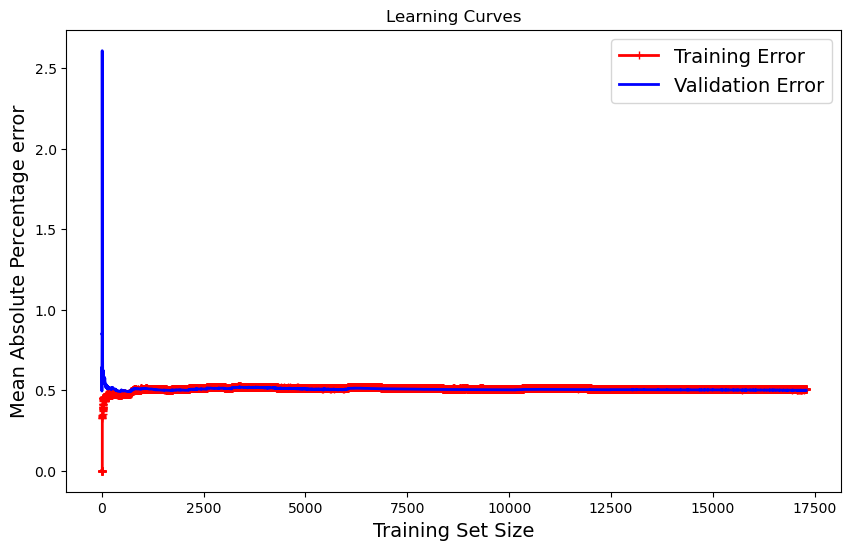

In [105]:
# Plot learning curves for Linear Regression
lin_reg = LinearRegression(n_jobs=-1)
plot_learning_curves(lin_reg, X_train, y_train, X_test, y_test)


Regularized Linear Models

Ridge Regression - Applies L2 regularization to prevent overfitting.

In [100]:
from sklearn.linear_model import Ridge

# Ridge Regression
ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_test)

print("Ridge Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))


Ridge Regression RMSE: 212540.13987359506


Lasso Regression - Applies L1 regularization to enforce sparsity and feature selection.

In [101]:
from sklearn.linear_model import Lasso

# Lasso Regression
lasso_reg = Lasso(alpha=0.1,max_iter=10000)
lasso_reg.fit(X_train, y_train)
y_pred_lasso = lasso_reg.predict(X_test)

print("Lasso Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))


Lasso Regression RMSE: 212539.5260270511


C:\Users\Lbundi\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.007e+13, tolerance: 2.259e+11
  model = cd_fast.enet_coordinate_descent(


Early Stopping

In [102]:
from sklearn.linear_model import ElasticNet

# Elastic Net Regression
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X_train, y_train)
y_pred_elastic = elastic_net.predict(X_test)

print("Elastic Net Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_elastic)))


Elastic Net Regression RMSE: 213354.04216794018


We'll use SGDRegressor with early stopping. This requires scaling the features and configuring the model for early stopping.

In [103]:
from sklearn.linear_model import SGDRegressor

# Scaling features for SGDRegressor
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SGD Regressor with Early Stopping
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, random_state=42)
sgd_reg.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_sgd = sgd_reg.predict(X_test_scaled)
print("SGD Regressor with Early Stopping RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_sgd)))


SGD Regressor with Early Stopping RMSE: 213250.34589183502
